# Разведочный анализ данных. Исследование и визуализация данных



## 1) Текстовое описание набора данных

В качестве набора данных используется **Optical Recognition of Handwritten Digits** из библиотеки Scikit-learn —
функция `sklearn.datasets.load_digits`.

- Документация: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html
- Исходное описание: https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

Набор содержит изображения рукописных цифр (0–9), сжатые до размера **8×8 пикселей**.
Каждый пиксель представлен целым числом от **0 до 16** (уровень серого).

**Задача классификации:** по 64 признакам (яркости пикселей) определить, какая цифра изображена.

Структура данных после загрузки:
- `data` — матрица размера (1797, 64), каждая строка — одно изображение;
- `target` — метка класса (цифра 0–9);
- `feature_names` — имена признаков вида `pixel_i_j` (строка i, столбец j сетки 8×8);
- `images` — те же данные в виде массива изображений 8×8 (удобно для визуализации).

Датасет небольшой, без пропусков, подходит для первой лабораторной работы.



# Импорт библиотек

Импортируем библиотеки по мере использования, как в учебном примере.



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

%matplotlib inline
sns.set(style="ticks")



# Загрузка данных

Загрузим датасет и преобразуем его в `pandas.DataFrame` (как рекомендуется в задании для наборов Scikit-learn).



In [ ]:
digits = load_digits()
data = pd.DataFrame(digits.data, columns=digits.feature_names)
data['target'] = digits.target



# 2) Основные характеристики датасета



In [ ]:
# Первые 5 строк датасета
data.head()



,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
# Размер датасета
data.shape



(1797, 65)

In [ ]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))



Всего строк: 1797


In [ ]:
# Список колонок
data.columns



Index(['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4',
       'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1',
       'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6',
       'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3',
       'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0',
       'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5',
       'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2',
       'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7',
       'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4',
       'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1',
       'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6',
       'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3',
       'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7', 'target'],
      dtype='str')

In [ ]:
# Список колонок с типами данных
data.dtypes



pixel_0_0    float64
pixel_0_1    float64
pixel_0_2    float64
pixel_0_3    float64
pixel_0_4    float64
              ...   
pixel_7_4    float64
pixel_7_5    float64
pixel_7_6    float64
pixel_7_7    float64
target         int64
Length: 65, dtype: object

In [ ]:
# Проверим наличие пустых значений
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))



pixel_0_0 - 0
pixel_0_1 - 0
pixel_0_2 - 0
pixel_0_3 - 0
pixel_0_4 - 0
pixel_0_5 - 0
pixel_0_6 - 0
pixel_0_7 - 0
pixel_1_0 - 0
pixel_1_1 - 0
pixel_1_2 - 0
pixel_1_3 - 0
pixel_1_4 - 0
pixel_1_5 - 0
pixel_1_6 - 0
pixel_1_7 - 0
pixel_2_0 - 0
pixel_2_1 - 0
pixel_2_2 - 0
pixel_2_3 - 0
pixel_2_4 - 0
pixel_2_5 - 0
pixel_2_6 - 0
pixel_2_7 - 0
pixel_3_0 - 0
pixel_3_1 - 0
pixel_3_2 - 0
pixel_3_3 - 0
pixel_3_4 - 0
pixel_3_5 - 0
pixel_3_6 - 0
pixel_3_7 - 0
pixel_4_0 - 0
pixel_4_1 - 0
pixel_4_2 - 0
pixel_4_3 - 0
pixel_4_4 - 0
pixel_4_5 - 0
pixel_4_6 - 0
pixel_4_7 - 0
pixel_5_0 - 0
pixel_5_1 - 0
pixel_5_2 - 0
pixel_5_3 - 0
pixel_5_4 - 0
pixel_5_5 - 0
pixel_5_6 - 0
pixel_5_7 - 0
pixel_6_0 - 0
pixel_6_1 - 0
pixel_6_2 - 0
pixel_6_3 - 0
pixel_6_4 - 0
pixel_6_5 - 0
pixel_6_6 - 0
pixel_6_7 - 0
pixel_7_0 - 0
pixel_7_1 - 0
pixel_7_2 - 0
pixel_7_3 - 0
pixel_7_4 - 0
pixel_7_5 - 0
pixel_7_6 - 0
pixel_7_7 - 0
target - 0


In [ ]:
# Основные статистические характеристики (числовые признаки)
data.describe()



,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [ ]:
# Уникальные значения целевого признака
data['target'].unique()



array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Целевой признак — **мультиклассовый**: 10 классов (цифры от 0 до 9).
Классы сбалансированы (примерно по 175–183 наблюдения на класс).



In [ ]:
# Распределение классов
data['target'].value_counts().sort_index()



target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

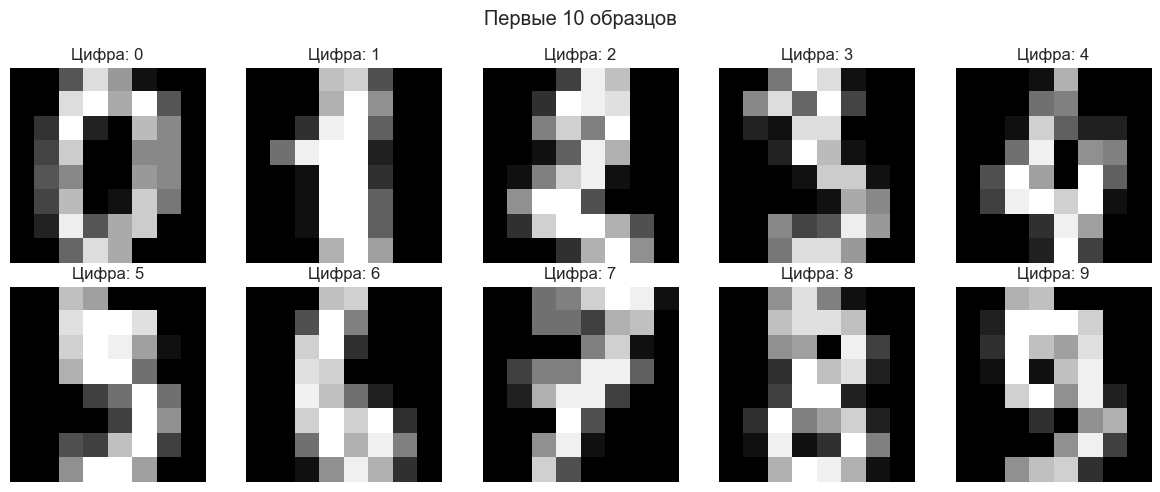

In [ ]:
# Примеры изображений из датасета
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, (idx, label) in zip(axes.ravel(), enumerate(digits.target[:10])):
    ax.imshow(digits.images[idx], cmap='gray')
    ax.set_title(f'Цифра: {label}')
    ax.axis('off')
plt.suptitle('Первые 10 образцов')
plt.tight_layout()



# 3) Визуальное исследование датасета

Для визуального исследования используем несколько распространённых типов диаграмм.
У датасета 64 признака-пикселя, поэтому для наглядности часть графиков строится по наиболее информативным пикселям и по подвыборке признаков.



### Диаграмма рассеяния

Позволяет увидеть совместное распределение двух признаков. В качестве примера возьмём пиксели с наибольшей по модулю корреляцией с `target` (см. раздел 4).



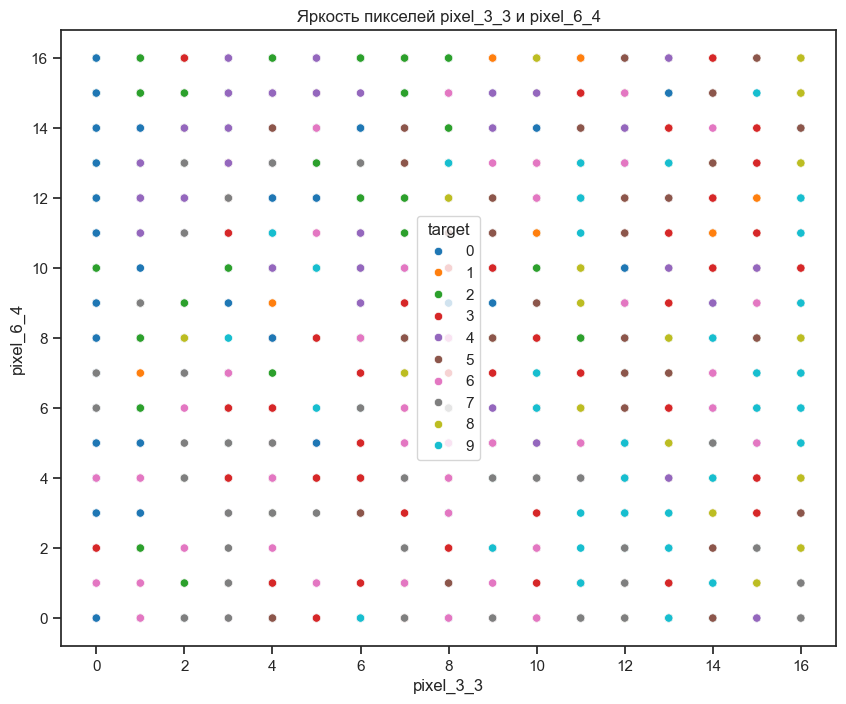

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(ax=ax, x='pixel_3_3', y='pixel_6_4', data=data, hue='target', palette='tab10')
ax.set_title('Яркость пикселей pixel_3_3 и pixel_6_4')
plt.show()



Кластеры по цветам соответствуют разным цифрам: центральные пиксели изображения сильнее разделяют классы, чем краевые.



## Гистограмма

Оценивает распределение значений одного признака.



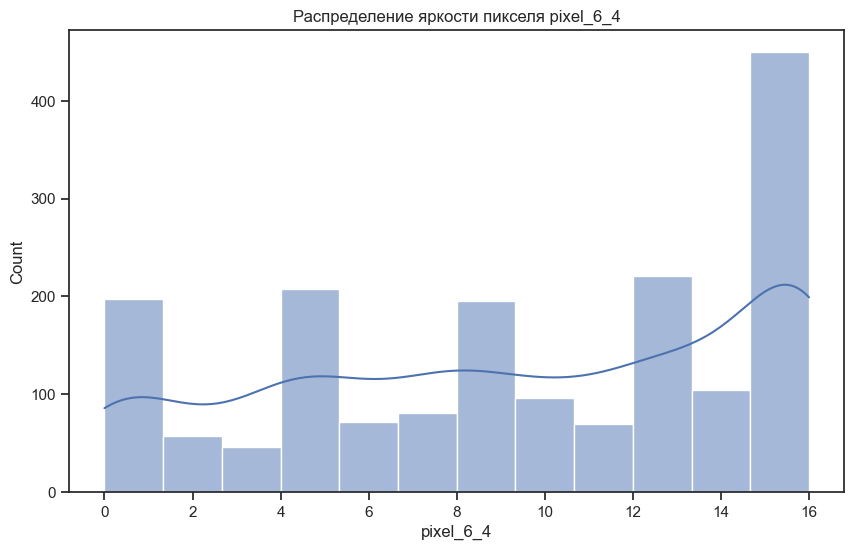

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data['pixel_6_4'], kde=True, ax=ax)
ax.set_title('Распределение яркости пикселя pixel_6_4')
plt.show()



### Jointplot
Комбинация гистограмм и диаграммы рассеяния.



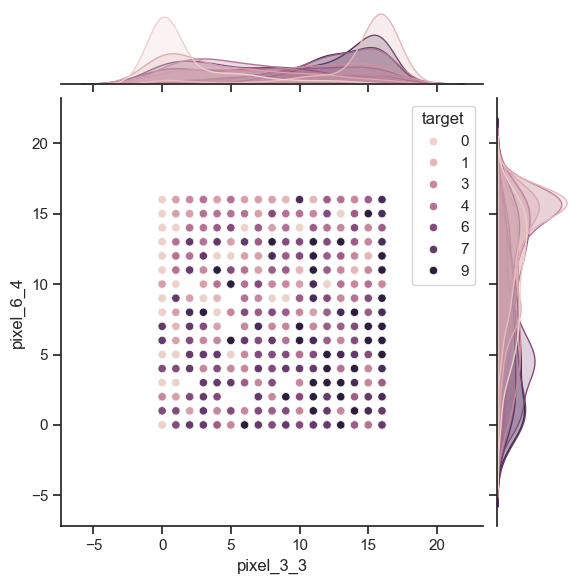

In [ ]:
sns.jointplot(x='pixel_3_3', y='pixel_6_4', data=data, hue='target')



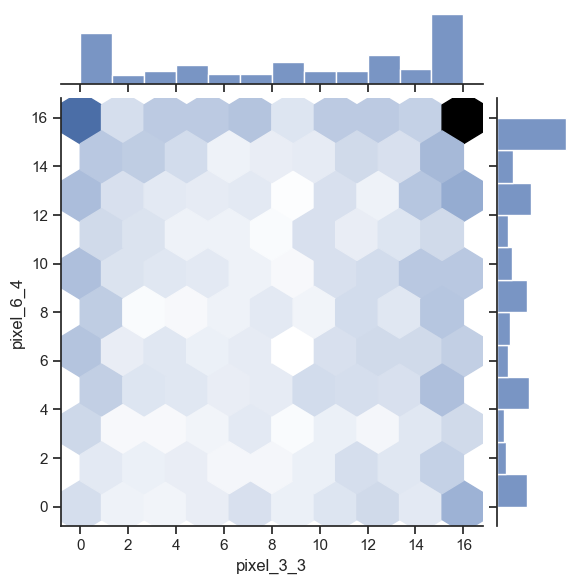

In [ ]:
sns.jointplot(x='pixel_3_3', y='pixel_6_4', data=data, kind='hex')



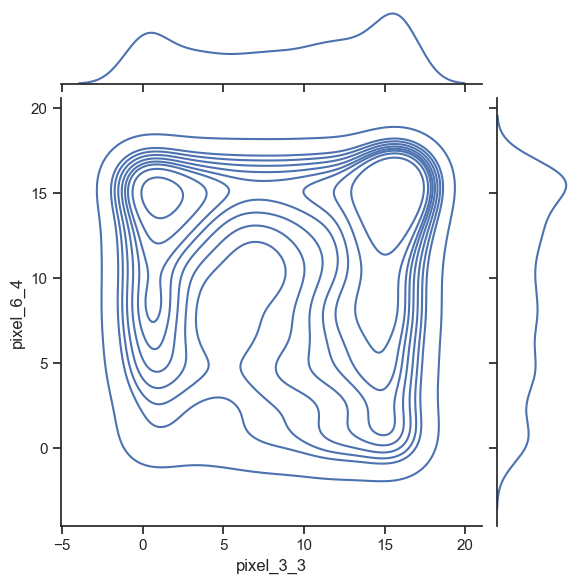

In [ ]:
sns.jointplot(x='pixel_3_3', y='pixel_6_4', data=data, kind='kde')



### Парные диаграммы

Для всего набора из 64 признаков `pairplot` неудобен, поэтому возьмём подмножество центральных пикселей.



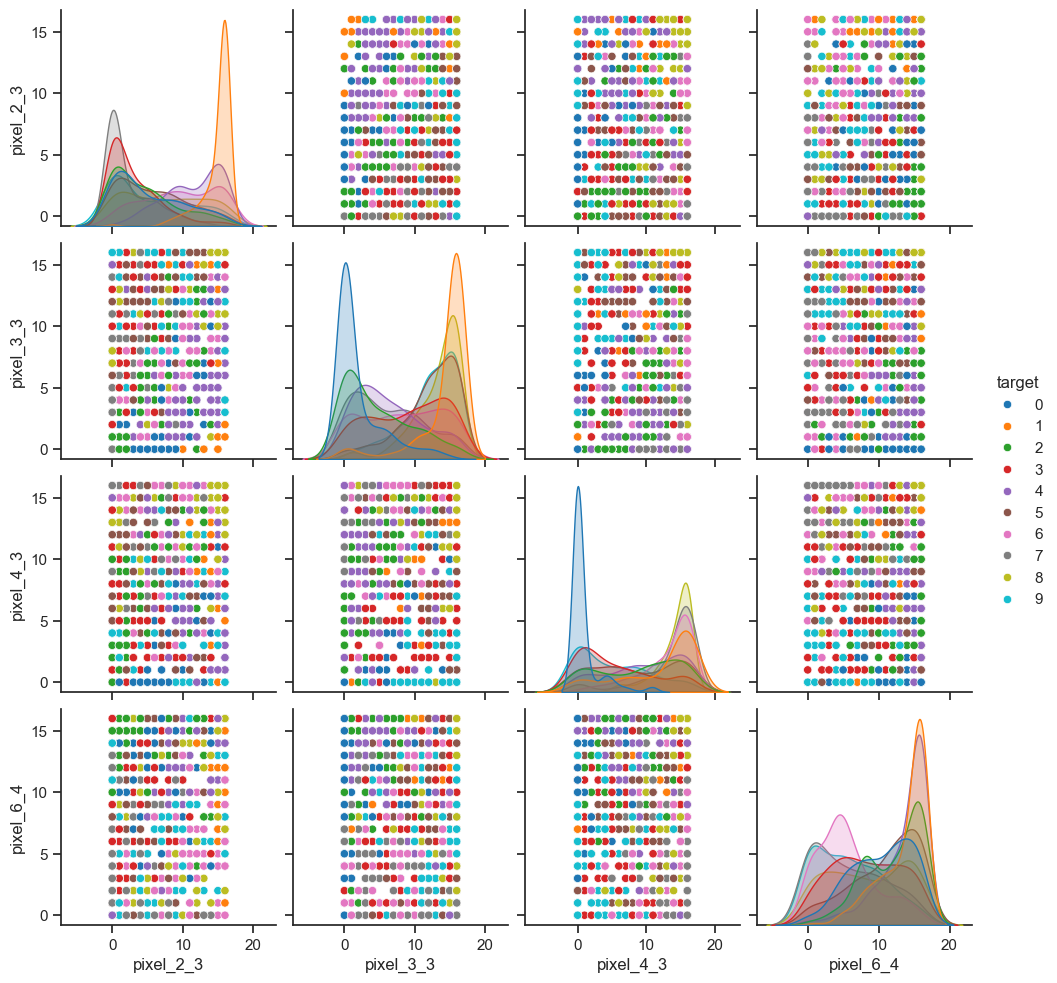

In [ ]:
subset_cols = ['pixel_2_3', 'pixel_3_3', 'pixel_4_3', 'pixel_6_4', 'target']
sns.pairplot(data[subset_cols], hue='target', palette='tab10')



С помощью параметра `hue` выполняется группировка по целевому признаку.



### Ящик с усами

Показывает распределение яркости пикселя в разрезе классов.



<Axes: xlabel='pixel_6_4'>

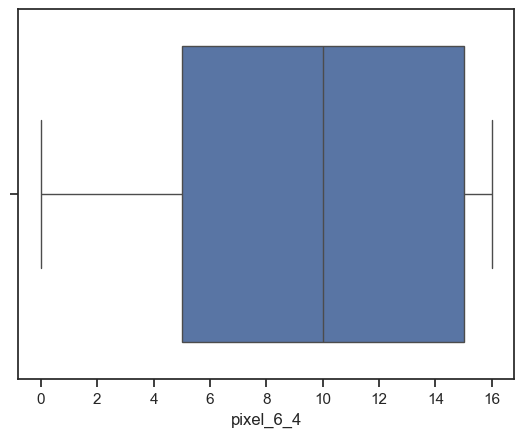

In [ ]:
sns.boxplot(x=data['pixel_6_4'])



<Axes: ylabel='pixel_6_4'>

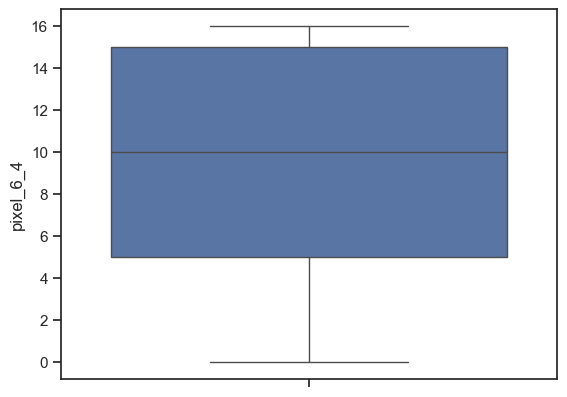

In [ ]:
# По вертикали
sns.boxplot(y=data['pixel_6_4'])



<Axes: xlabel='target', ylabel='pixel_6_4'>

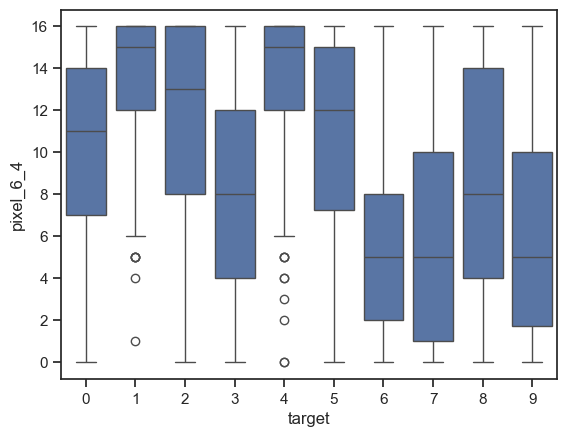

In [ ]:
sns.boxplot(x='target', y='pixel_6_4', data=data)



### Violin plot

Аналогичен boxplot, но дополнительно отображает оценку плотности распределения.



<Axes: xlabel='pixel_6_4'>

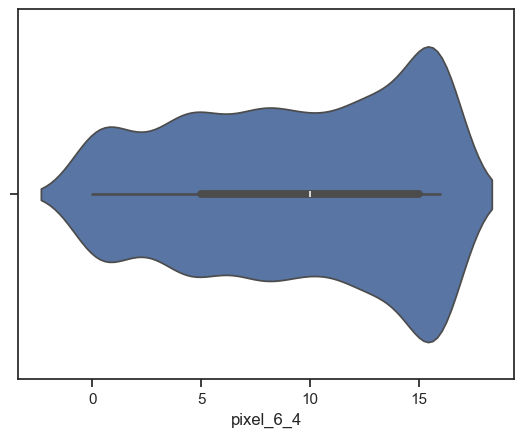

In [ ]:
sns.violinplot(x=data['pixel_6_4'])



<Axes: xlabel='pixel_6_4', ylabel='Count'>

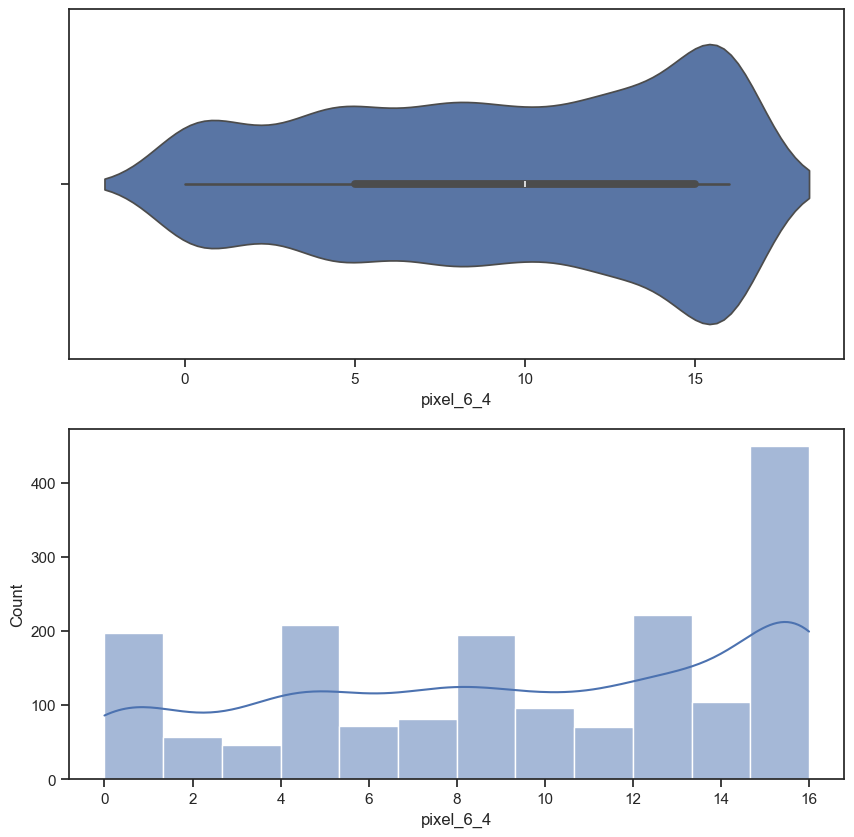

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
sns.violinplot(ax=ax[0], x=data['pixel_6_4'])
sns.histplot(data['pixel_6_4'], kde=True, ax=ax[1])



На гистограмме и violin plot видно, что значения яркости сконцентрированы в нижней части диапазона (фон изображения).



<Axes: xlabel='target', ylabel='pixel_6_4'>

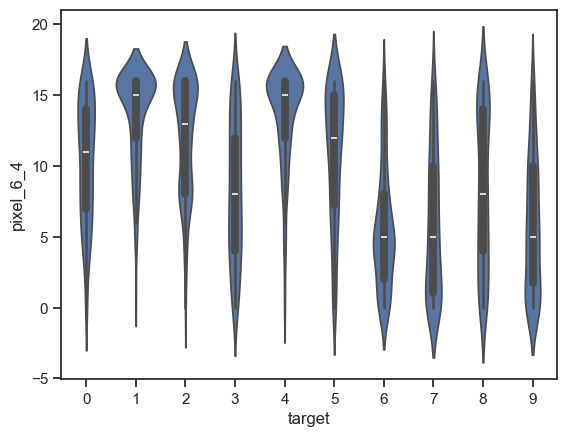

In [ ]:
sns.violinplot(x='target', y='pixel_6_4', data=data)



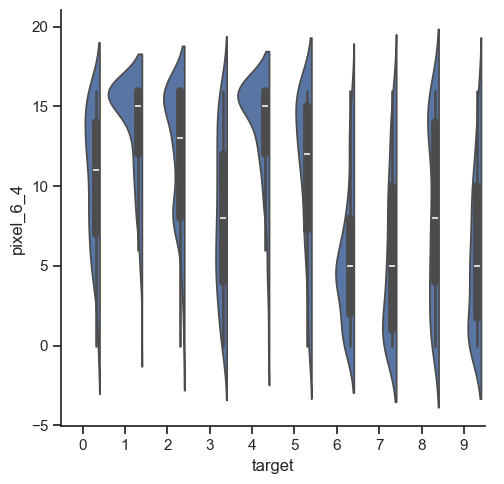

In [ ]:
sns.catplot(y="pixel_6_4", x="target", data=data, kind="violin", split=True)



# 4) Информация о корреляции признаков



Проверка корреляции признаков позволяет:
1. Понять, какие признаки сильнее связаны с целевой переменной `target`.
2. Выявить линейно зависимые признаки (соседние пиксели часто коррелируют), что важно при отборе признаков для моделей.



In [ ]:
# Удалим константные признаки (иначе в матрице корреляций появятся NaN)
constant_cols = [col for col in data.columns if col != 'target' and data[col].nunique() <= 1]
print('Константные признаки:', constant_cols)
data_corr = data.drop(columns=constant_cols)



Константные признаки: ['pixel_0_0', 'pixel_4_0', 'pixel_4_7']


In [ ]:
data_corr.corr()



,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
pixel_0_1,1.000000,0.556618,0.207814,-0.018761,0.060776,0.048388,-0.038927,0.032320,0.556372,0.224522,...,-0.045342,-0.007905,0.855610,0.555727,0.147646,-0.102349,-0.029870,0.026547,-0.043889,-0.051834
pixel_0_2,0.556618,1.000000,0.560180,-0.084235,0.043569,0.002841,-0.062278,0.022311,0.582259,0.631467,...,-0.003804,-0.025837,0.515276,0.937623,0.499840,-0.134754,-0.041183,0.072599,0.082523,-0.011836
pixel_0_3,0.207814,0.560180,1.000000,0.023938,-0.171377,-0.115732,-0.040139,0.035663,0.328344,0.596480,...,0.075335,-0.049085,0.175804,0.560326,0.767945,-0.065957,-0.054936,0.053437,0.081971,-0.011489
pixel_0_4,-0.018761,-0.084235,0.023938,1.000000,0.507731,0.127764,0.010065,0.042065,0.051657,0.013998,...,-0.212220,0.017352,-0.047223,-0.020176,-0.008867,-0.082125,-0.215809,-0.250699,-0.215349,0.100801
pixel_0_5,0.060776,0.043569,-0.171377,0.507731,1.000000,0.607309,0.154095,0.000189,0.038540,0.072170,...,-0.188665,0.030067,0.063367,0.097079,-0.068038,-0.351146,-0.268818,-0.267659,-0.167727,0.193362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel_7_4,-0.102349,-0.134754,-0.065957,-0.082125,-0.351146,-0.383522,-0.178243,0.048996,-0.000604,-0.077451,...,0.105101,0.005697,-0.117908,-0.207957,0.058390,1.000000,0.609515,0.243305,0.103015,-0.196083
pixel_7_5,-0.029870,-0.041183,-0.054936,-0.215809,-0.268818,-0.304111,-0.141174,0.033409,0.071488,-0.031067,...,0.262795,-0.003056,-0.043889,-0.091839,-0.094956,0.609515,1.000000,0.648328,0.261991,-0.079100
pixel_7_6,0.026547,0.072599,0.053437,-0.250699,-0.267659,-0.178945,-0.063220,0.020689,0.111569,0.005106,...,0.511726,-0.011932,0.014557,0.035369,0.006849,0.243305,0.648328,1.000000,0.620428,-0.114007
pixel_7_7,-0.043889,0.082523,0.081971,-0.215349,-0.167727,-0.080309,-0.024505,-0.005226,-0.001404,0.001910,...,0.563989,-0.004625,-0.047089,0.031193,0.099671,0.103015,0.261991,0.620428,1.000000,-0.181929


Корреляционная матрица симметрична относительно главной диагонали; на диагонали — единицы.

Для пикселей корреляция с `target` по модулю, как правило, **умеренная** (до ~0.4), потому что класс определяется совместным паттерном многих пикселей, а не одним признаком.



На основе корреляционной матрицы можно сделать выводы:
- С `target` сильнее всего (по модулю) связаны центральные пиксели, например `pixel_6_4`, `pixel_3_3`, `pixel_4_3`.
- Краевые и угловые пиксели (`pixel_0_0`, `pixel_4_0`, `pixel_4_7`) константны (всегда 0) — их следует исключить из анализа и модели.
- Соседние пиксели часто коррелируют между собой; при построении линейных моделей имеет смысл не дублировать сильно связанные признаки.



Описание метода `corr`: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

По умолчанию используется коэффициент корреляции Пирсона; также доступны Kendall и Spearman.



In [ ]:
data_corr.corr(method='pearson')



,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
pixel_0_1,1.000000,0.556618,0.207814,-0.018761,0.060776,0.048388,-0.038927,0.032320,0.556372,0.224522,...,-0.045342,-0.007905,0.855610,0.555727,0.147646,-0.102349,-0.029870,0.026547,-0.043889,-0.051834
pixel_0_2,0.556618,1.000000,0.560180,-0.084235,0.043569,0.002841,-0.062278,0.022311,0.582259,0.631467,...,-0.003804,-0.025837,0.515276,0.937623,0.499840,-0.134754,-0.041183,0.072599,0.082523,-0.011836
pixel_0_3,0.207814,0.560180,1.000000,0.023938,-0.171377,-0.115732,-0.040139,0.035663,0.328344,0.596480,...,0.075335,-0.049085,0.175804,0.560326,0.767945,-0.065957,-0.054936,0.053437,0.081971,-0.011489
pixel_0_4,-0.018761,-0.084235,0.023938,1.000000,0.507731,0.127764,0.010065,0.042065,0.051657,0.013998,...,-0.212220,0.017352,-0.047223,-0.020176,-0.008867,-0.082125,-0.215809,-0.250699,-0.215349,0.100801
pixel_0_5,0.060776,0.043569,-0.171377,0.507731,1.000000,0.607309,0.154095,0.000189,0.038540,0.072170,...,-0.188665,0.030067,0.063367,0.097079,-0.068038,-0.351146,-0.268818,-0.267659,-0.167727,0.193362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel_7_4,-0.102349,-0.134754,-0.065957,-0.082125,-0.351146,-0.383522,-0.178243,0.048996,-0.000604,-0.077451,...,0.105101,0.005697,-0.117908,-0.207957,0.058390,1.000000,0.609515,0.243305,0.103015,-0.196083
pixel_7_5,-0.029870,-0.041183,-0.054936,-0.215809,-0.268818,-0.304111,-0.141174,0.033409,0.071488,-0.031067,...,0.262795,-0.003056,-0.043889,-0.091839,-0.094956,0.609515,1.000000,0.648328,0.261991,-0.079100
pixel_7_6,0.026547,0.072599,0.053437,-0.250699,-0.267659,-0.178945,-0.063220,0.020689,0.111569,0.005106,...,0.511726,-0.011932,0.014557,0.035369,0.006849,0.243305,0.648328,1.000000,0.620428,-0.114007
pixel_7_7,-0.043889,0.082523,0.081971,-0.215349,-0.167727,-0.080309,-0.024505,-0.005226,-0.001404,0.001910,...,0.563989,-0.004625,-0.047089,0.031193,0.099671,0.103015,0.261991,0.620428,1.000000,-0.181929


In [ ]:
data_corr.corr(method='kendall')



,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
pixel_0_1,1.000000,0.465882,0.256522,0.038614,0.029441,0.062169,-0.048597,0.067609,0.515746,0.221959,...,-0.017027,-0.009556,0.677321,0.471248,0.221563,-0.033074,-0.003165,0.056966,0.000990,-0.040492
pixel_0_2,0.465882,1.000000,0.506751,0.011530,0.037044,0.026456,-0.053528,0.026521,0.505813,0.545036,...,0.029622,-0.026739,0.432331,0.835192,0.486278,-0.066101,-0.034704,0.025642,0.091449,0.008607
pixel_0_3,0.256522,0.506751,1.000000,0.079054,-0.087038,-0.095483,-0.059491,0.029306,0.294348,0.341575,...,0.065269,-0.030482,0.207891,0.507393,0.468383,0.008530,-0.024476,0.035779,0.101062,-0.042824
pixel_0_4,0.038614,0.011530,0.079054,1.000000,0.496506,0.181453,-0.000730,0.044320,0.097564,0.059772,...,-0.155221,0.014554,-0.012783,0.038562,0.053911,-0.046014,-0.161454,-0.183123,-0.155410,0.080654
pixel_0_5,0.029441,0.037044,-0.087038,0.496506,1.000000,0.573693,0.160876,0.014179,0.058851,0.066711,...,-0.211238,0.023488,0.030512,0.058292,0.020164,-0.207973,-0.196805,-0.242094,-0.197487,0.132804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel_7_4,-0.033074,-0.066101,0.008530,-0.046014,-0.207973,-0.300862,-0.159818,0.060314,0.020910,-0.025894,...,0.114478,-0.003947,-0.051525,-0.091247,0.083071,1.000000,0.530071,0.307113,0.095293,-0.083886
pixel_7_5,-0.003165,-0.034704,-0.024476,-0.161454,-0.196805,-0.255171,-0.164188,0.034370,0.041364,-0.021996,...,0.269659,-0.000315,-0.023451,-0.057295,-0.048574,0.530071,1.000000,0.660547,0.264027,-0.076228
pixel_7_6,0.056966,0.025642,0.035779,-0.183123,-0.242094,-0.223923,-0.105993,0.015769,0.090812,0.007816,...,0.423324,-0.015185,0.027867,0.016049,-0.015865,0.307113,0.660547,1.000000,0.447316,-0.048620
pixel_7_7,0.000990,0.091449,0.101062,-0.155410,-0.197487,-0.131793,-0.041462,0.019413,0.031035,0.034887,...,0.696051,-0.005940,-0.012840,0.060693,0.087270,0.095293,0.264027,0.447316,1.000000,-0.143233


In [ ]:
data_corr.corr(method='spearman')



,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
pixel_0_1,1.000000,0.546549,0.306121,0.045618,0.034906,0.067141,-0.050107,0.069335,0.574771,0.266430,...,-0.017636,-0.009799,0.695570,0.554887,0.262853,-0.038959,-0.003872,0.062895,0.001071,-0.048067
pixel_0_2,0.546549,1.000000,0.643599,0.014205,0.049032,0.032624,-0.063069,0.031093,0.628635,0.702562,...,0.035197,-0.031345,0.509189,0.943023,0.616808,-0.090226,-0.047479,0.033075,0.109046,0.003901
pixel_0_3,0.306121,0.643599,1.000000,0.109956,-0.118404,-0.116923,-0.069967,0.034186,0.369092,0.445723,...,0.077149,-0.035535,0.247587,0.646538,0.570535,0.010499,-0.032816,0.045415,0.119529,-0.067370
pixel_0_4,0.045618,0.014205,0.109956,1.000000,0.630281,0.221711,-0.000879,0.051690,0.122804,0.083223,...,-0.183476,0.016959,-0.014930,0.053984,0.075355,-0.068580,-0.217234,-0.229098,-0.183080,0.115201
pixel_0_5,0.034906,0.049032,-0.118404,0.630281,1.000000,0.684871,0.188753,0.016576,0.075102,0.090739,...,-0.249566,0.027404,0.036149,0.075965,0.028808,-0.280185,-0.258933,-0.301882,-0.233633,0.188733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel_7_4,-0.038959,-0.090226,0.010499,-0.068580,-0.280185,-0.364332,-0.185451,0.069643,0.026076,-0.034368,...,0.133914,-0.004556,-0.060110,-0.126268,0.110864,1.000000,0.672410,0.383310,0.111429,-0.112225
pixel_7_5,-0.003872,-0.047479,-0.032816,-0.217234,-0.258933,-0.312460,-0.192483,0.040156,0.051320,-0.029378,...,0.318113,-0.000368,-0.027860,-0.075534,-0.065122,0.672410,1.000000,0.786449,0.311382,-0.104000
pixel_7_6,0.062895,0.033075,0.045415,-0.229098,-0.301882,-0.253628,-0.114962,0.017001,0.106297,0.010224,...,0.461842,-0.016377,0.030730,0.021227,-0.018654,0.383310,0.786449,1.000000,0.483112,-0.059124
pixel_7_7,0.001071,0.109046,0.119529,-0.183080,-0.233633,-0.140970,-0.042270,0.019685,0.034579,0.041192,...,0.714031,-0.006021,-0.013251,0.072617,0.102549,0.111429,0.311382,0.483112,1.000000,-0.168184


При большом числе признаков удобнее **тепловая карта** (`heatmap`).

Для читаемости построим карту по подвыборке центральных пикселей 4×4.



<Axes: >

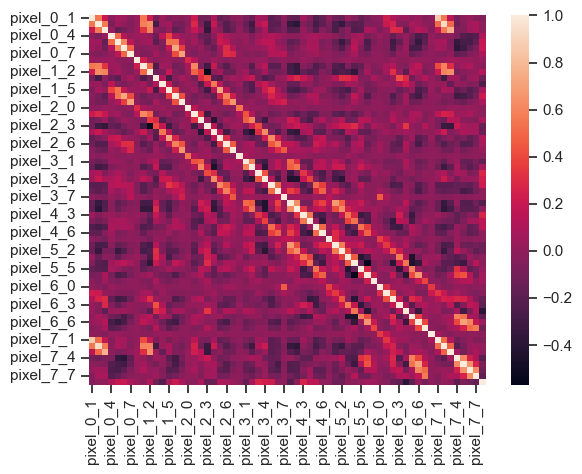

In [ ]:
sns.heatmap(data_corr.corr())



<Axes: >

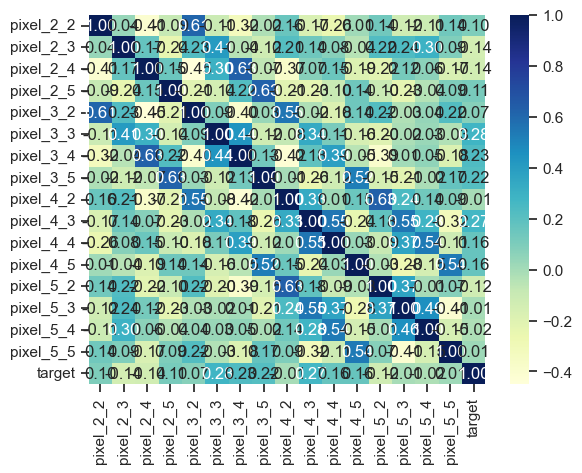

In [ ]:
center_pixels = [
    'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5',
    'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5',
    'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5',
    'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5',
    'target',
]
sns.heatmap(data_corr[center_pixels].corr(), annot=True, fmt='.2f', cmap='YlGnBu')



<Axes: >

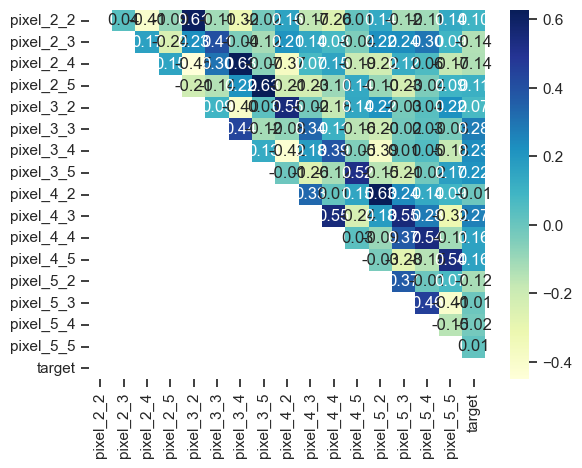

In [ ]:
mask = np.zeros_like(data_corr[center_pixels].corr(), dtype=bool)
mask[np.tril_indices_from(mask)] = True
sns.heatmap(
    data_corr[center_pixels].corr(),
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
)



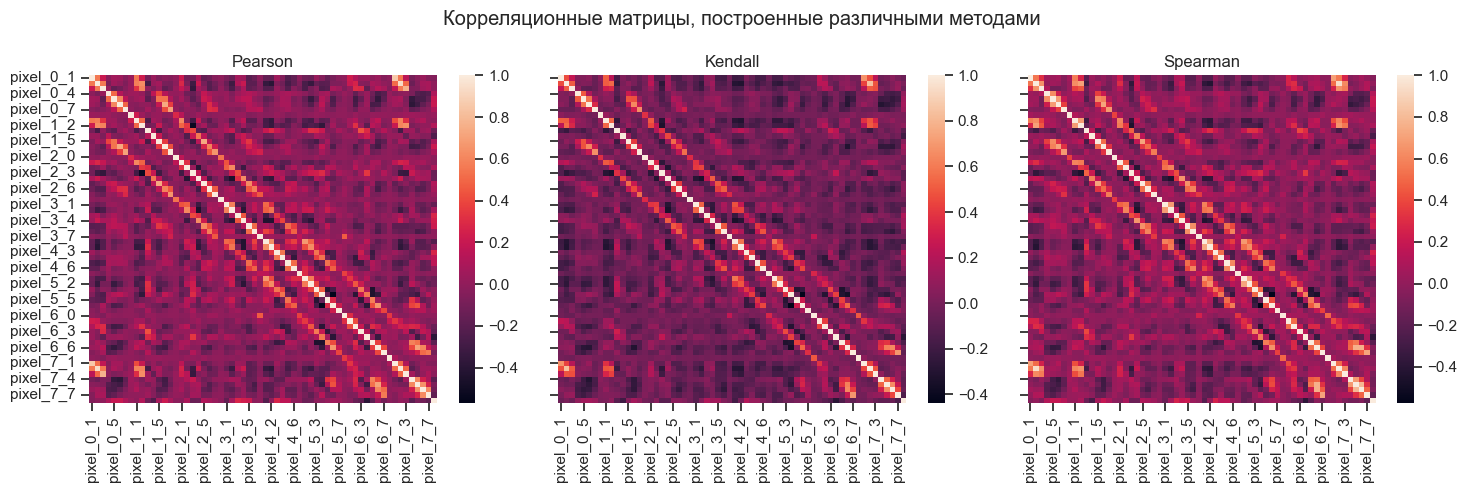

In [ ]:
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15, 5))
sns.heatmap(data_corr.corr(method='pearson'), ax=ax[0], annot=False)
sns.heatmap(data_corr.corr(method='kendall'), ax=ax[1], annot=False)
sns.heatmap(data_corr.corr(method='spearman'), ax=ax[2], annot=False)
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].set_title('Pearson')
ax[1].set_title('Kendall')
ax[2].set_title('Spearman')
plt.tight_layout()



In [ ]:
# Корреляция признаков с целевой переменной
target_corr = (
    data_corr.corr()['target']
    .drop('target')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
target_corr.head(15)



pixel_6_4   -0.390625
pixel_3_3    0.275468
pixel_4_3    0.265880
pixel_1_4   -0.244489
pixel_3_4    0.234159
pixel_4_1   -0.223413
pixel_3_5    0.216130
pixel_1_6    0.209664
pixel_0_6    0.197343
pixel_7_4   -0.196083
pixel_0_5    0.193362
pixel_6_5   -0.189452
pixel_7_7   -0.181929
pixel_6_3   -0.181037
pixel_3_1   -0.169231
Name: target, dtype: float64

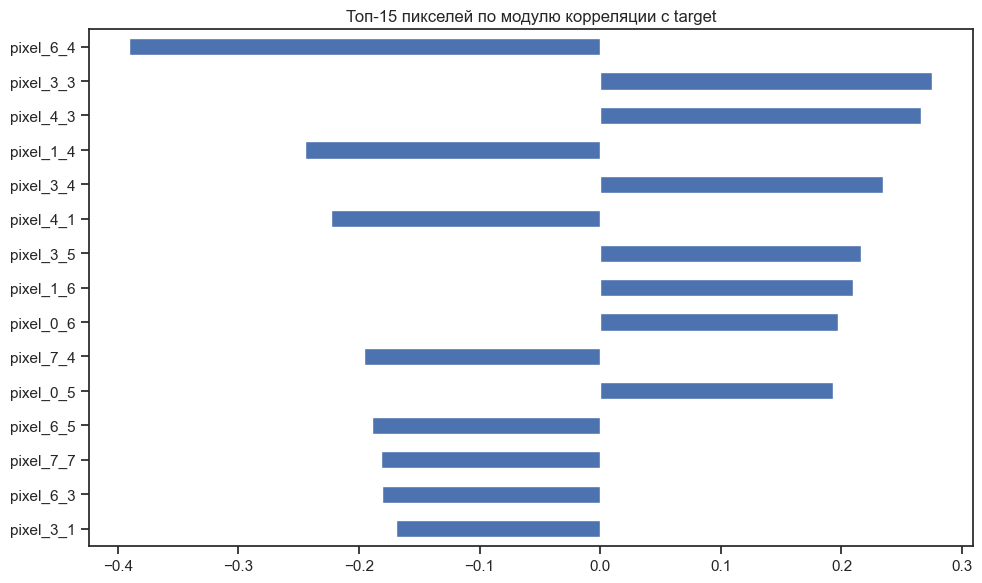

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
target_corr.head(15).plot(kind='barh', ax=ax)
ax.set_title('Топ-15 пикселей по модулю корреляции с target')
ax.invert_yaxis()
plt.tight_layout()



Тепловая карта хорошо показывает блоки высокой корреляции между соседними пикселями в центре изображения.

Для отбора признаков в модели машинного обучения обычно оставляют информативные центральные пиксели и исключают константные краевые.

